In [73]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt 
 

In [74]:
df=pd.read_csv(r"C:\Users\LENOVO\Downloads\Restorant- Sales-Data-Analysis.csv")
df.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin


In [75]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        254 non-null    int64  
 1   Date            254 non-null    object 
 2   Product         254 non-null    object 
 3   Price           254 non-null    float64
 4   Quantity        254 non-null    float64
 5   Purchase Type   254 non-null    object 
 6   Payment Method  254 non-null    object 
 7   Manager         254 non-null    object 
 8   City            254 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 18.0+ KB


,Order ID,Price,Quantity
count,254.000000,254.000000,254.000000
mean,10584.133858,7.102323,460.611457
std,75.889181,4.341855,214.888699
min,10452.000000,2.950000,200.400000
25%,10520.250000,3.490000,201.010000
50%,10583.500000,4.990000,538.880000
75%,10649.750000,9.950000,677.440000
max,10713.000000,29.050000,754.430000


In [76]:

df.duplicated().sum()

0

In [77]:
df["Revenue"]= df["Price"] * df["Quantity"]
df.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Revenue
0,10452,07-11-2022,Fries,3.49,573.07,Online,Gift Card,Tom Jackson,London,2000.0143
1,10453,07-11-2022,Beverages,2.95,745.76,Online,Gift Card,Pablo Perez,Madrid,2199.9920
2,10454,07-11-2022,Sides & Other,4.99,200.40,In-store,Gift Card,Joao Silva,Lisbon,999.9960
3,10455,08-11-2022,Burgers,12.99,569.67,In-store,Credit Card,Walter Muller,Berlin,7400.0133
4,10456,08-11-2022,Chicken Sandwiches,9.95,201.01,In-store,Credit Card,Walter Muller,Berlin,2000.0495


In [78]:
df["Revenue"].describe()

count      254.000000
mean      3029.589997
std       2420.118378
min        999.996000
25%       2000.011500
50%       2100.020400
75%       2400.003200
max      16074.435000
Name: Revenue, dtype: float64

In [79]:
df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

Product
Burgers               376999.8069
Fries                 125674.2903
Chicken Sandwiches    114641.6950
Beverages             103200.2630
Sides & Other          48999.8040
Name: Revenue, dtype: float64

In [80]:
df.groupby("City")["Revenue"].sum().sort_values(ascending=False)

City
Lisbon    241714.1157
London    211201.0406
Madrid    136200.2665
Berlin    100600.1313
Paris      79800.3051
Name: Revenue, dtype: float64

In [81]:
df.groupby("Payment Method")["Revenue"].sum()

Payment Method
Cash           239200.2355
Credit Card    361715.0265
Gift Card      168600.5972
Name: Revenue, dtype: float64

produk mana yang mahal per transaksi ?

In [82]:
df.groupby("Product")["Revenue"].mean().sort_values(ascending=False)

Product
Burgers               7249.996287
Fries                 2464.201771
Chicken Sandwiches    2204.647981
Beverages             2064.005260
Sides & Other          999.996000
Name: Revenue, dtype: float64

Produk apa yg laku dikota mana ?

In [83]:
df.groupby(["Product", "City"])["Revenue"].sum()

Product             City  
Beverages           Berlin     12000.0690
                    Lisbon     33600.0280
                    London     28800.0830
                    Madrid     18400.0645
                    Paris      10400.0185
Burgers             Berlin     53399.9415
                    Lisbon    108799.8234
                    London    101800.2918
                    Madrid     73599.7812
                    Paris      39399.9690
Chicken Sandwiches  Berlin     16000.1970
                    Lisbon     36639.9635
                    London     32000.7920
                    Madrid     18000.4455
                    Paris      12000.2970
Fries               Berlin     13199.9478
                    Lisbon     47674.3608
                    London     34599.9298
                    Madrid     17200.0113
                    Paris      13000.0406
Sides & Other       Berlin      5999.9760
                    Lisbon     14999.9400
                    London     13999.9440
       

Produk apa yg sering dipakai dengan alat pembayaran apa

In [84]:
df.groupby(["Product", "Payment Method"])["Revenue"].sum()

Product             Payment Method
Beverages           Cash               31600.0165
                    Credit Card        44800.1750
                    Gift Card          26800.0715
Burgers             Cash              124799.7363
                    Credit Card       173599.9188
                    Gift Card          78600.1518
Chicken Sandwiches  Cash               34200.6375
                    Credit Card        55840.5780
                    Gift Card          24600.4795
Fries               Cash               33599.9052
                    Credit Card        65474.4427
                    Gift Card          26599.9424
Sides & Other       Cash               14999.9400
                    Credit Card        21999.9120
                    Gift Card          11999.9520
Name: Revenue, dtype: float64

In [85]:
df.groupby("City")["Revenue"].mean()

City
Berlin    3353.337710
Lisbon    3222.854876
London    2816.013875
Madrid    2960.875359
Paris     2850.010896
Name: Revenue, dtype: float64

In [86]:
df.groupby("City")["Revenue"].count()

City
Berlin    30
Lisbon    75
London    75
Madrid    46
Paris     28
Name: Revenue, dtype: int64

In [87]:
df.groupby("City")["Revenue"].median()

City
Berlin    2199.9913
Lisbon    2199.9920
London    2000.0495
Madrid    2000.0495
Paris     2000.0495
Name: Revenue, dtype: float64

In [88]:
df.groupby("Product")["Revenue"].mean()

Product
Beverages             2064.005260
Burgers               7249.996287
Chicken Sandwiches    2204.647981
Fries                 2464.201771
Sides & Other          999.996000
Name: Revenue, dtype: float64

In [89]:
df.groupby("Product")["Revenue"].median()

Product
Beverages             2000.0115
Burgers               7000.0512
Chicken Sandwiches    2000.0495
Fries                 2199.9913
Sides & Other          999.9960
Name: Revenue, dtype: float64

In [90]:
df.groupby("Product")["Revenue"].count()

Product
Beverages             50
Burgers               52
Chicken Sandwiches    52
Fries                 51
Sides & Other         49
Name: Revenue, dtype: int64

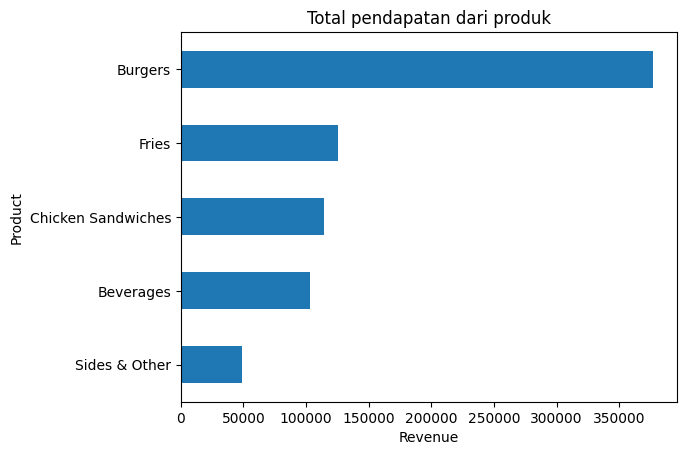

In [91]:
import matplotlib.pyplot as plt

product_rev = df.groupby("Product")["Revenue"].sum().sort_values()

plt.figure()
product_rev.plot(kind="barh")
plt.title("Total pendapatan dari produk")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

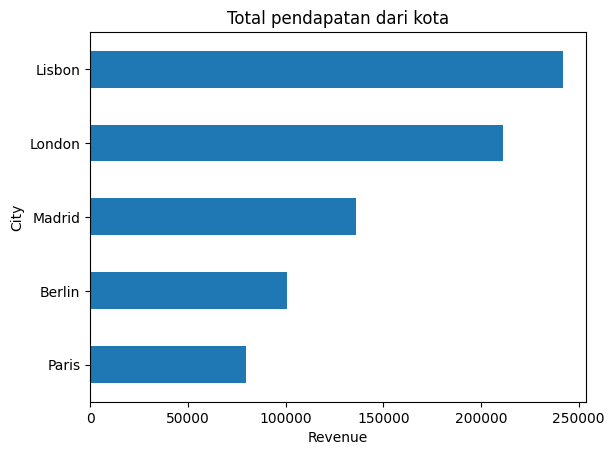

In [92]:
city_rev = df.groupby("City")["Revenue"].sum().sort_values()

plt.figure()
city_rev.plot(kind="barh")
plt.title("Total pendapatan dari kota")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.show()

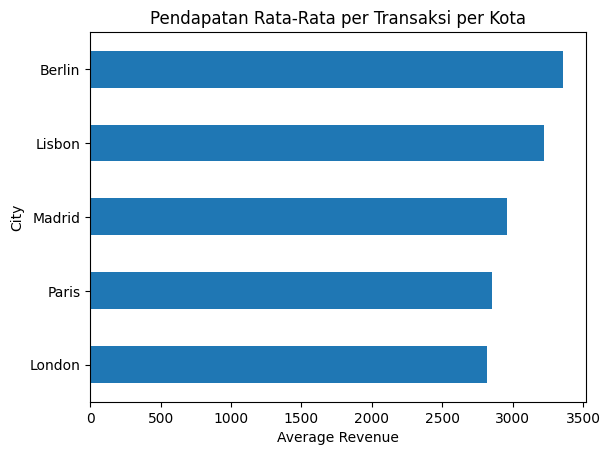

In [93]:
city_mean = df.groupby("City")["Revenue"].mean().sort_values()

plt.figure()
city_mean.plot(kind="barh")
plt.title("Pendapatan Rata-Rata per Transaksi per Kota")
plt.xlabel("Average Revenue")
plt.ylabel("City")
plt.show()

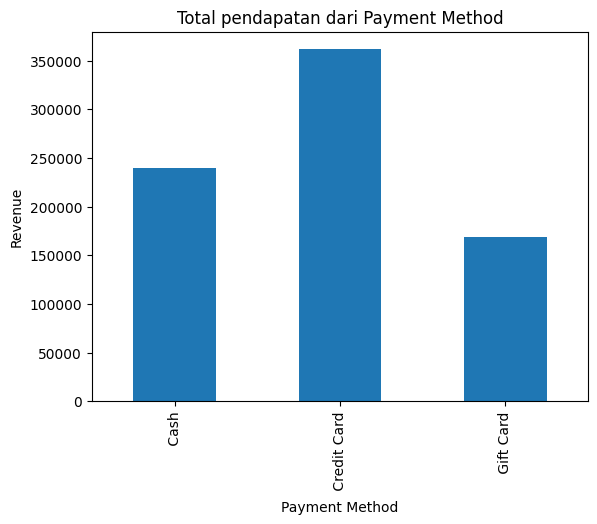

In [94]:
payment_rev = df.groupby("Payment Method")["Revenue"].sum()

plt.figure()
payment_rev.plot(kind="bar")
plt.title("Total pendapatan dari Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")
plt.show()

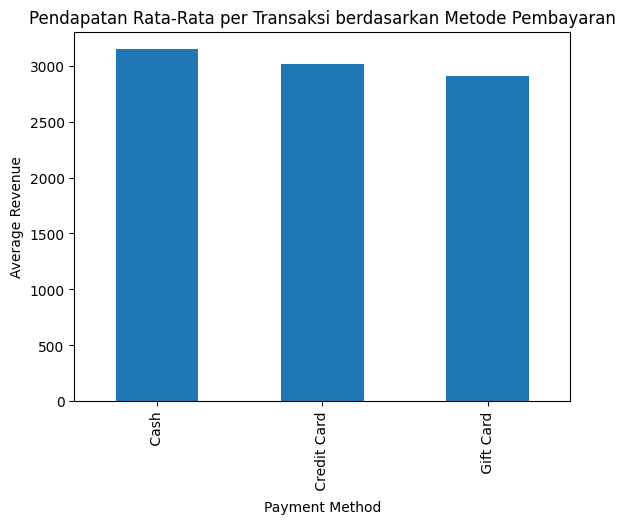

In [95]:
payment_mean = df.groupby("Payment Method")["Revenue"].mean()

plt.figure()
payment_mean.plot(kind="bar")
plt.title("Pendapatan Rata-Rata per Transaksi berdasarkan Metode Pembayaran")
plt.xlabel("Payment Method")
plt.ylabel("Average Revenue")
plt.show()

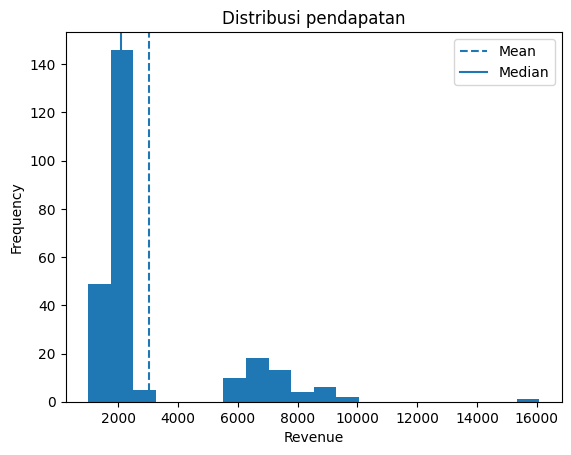

In [96]:
import numpy as np

mean = df["Revenue"].mean()
median = df["Revenue"].median()

plt.figure()
plt.hist(df["Revenue"], bins=20)
plt.axvline(mean, linestyle="dashed", label="Mean")
plt.axvline(median, linestyle="solid", label="Median")
plt.legend()
plt.title("Distribusi pendapatan")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()